-----------------------------------------------------------------------------------------------------------------------------------------------------------
Mini Project: Indian Kids Screen Time | EDA
-----------------------------------------------------------------------------------------------------------------------------------------------------------

Fenti Devita
-----------------------------------------------------------------------------------------------------------------------------------------------------------

This notebook documents the initial process of investigating data to understand its characteristics, find patterns, anomalies and relationships between variables using visualization and descriptive statistics before further analysis or modeling or what is called Exploratory Data Analysis.

The Indian Kids Screen Time dataset is one of 9 datasets provided as a Mini Project theme in the process of initial investigation of data to understand the structure, patterns, anomalies and relationships between variables, which usually uses descriptive statistical techniques and data visualization, before more in-depth analysis or modeling is carried out.

This dataset conveys the screen usage habits of children in India presented in .csv form. The aim of EDA is to recognize the condition of the data and apply the basic concepts of data cleaning and the importance of this process in data analysis before the data is ready for further analysis with visualization.

# 1. Reading and Extracting Data
   
This data is displayed in a notebook with a DataFrame and the Data Preparation process uses several tools from the library such as Panda Numpy, Matplotlib, Scipy, and Seaborn.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

df_data = pd.read_csv("Indian_Kids_Screen_Time.csv") #Displays the top data from the dataset. 
df_data

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


## The meaning of each header for data recognition:

- Age: The child's age, which according to the World Health Organization (WHO) is from conception to 18 years of age.

- Gender: The child's sex (male or female).

- Avg_Daily_Screen_Time_hr: Average time spent in front of a screen per day in hours (including mobile phones, TVs, tablets, and laptops).

- Primary_Device: The primary device most frequently used (e.g., smartphone, laptop, TV, or tablet).

- Exceeded_Recommended_Limit: A Boolean value (True/False) indicating whether the child's screen time exceeds the limit recommended by health guidelines. Values exceeding the recommended time are marked "True," and values not exceeding the recommended time are marked "False." According to the World Health Organization (WHO) and the American Academy of Pediatrics (AAP), the recommended limit for screen time is 1 to 2 hours per day.

- Educational_to_Recreational_Ratio: The ratio of time spent on education (studying) versus recreation (entertainment).

- Health_Impacts: Reported or perceived health impacts due to screen use (e.g., sleep disturbances, eyestrain, or anxiety).

- Urban_or_Rural: The child's residence classification, whether urban or rural.



## a. Basic Information, Form, Structure, and Types of Data

In [66]:
print("\n--- Informasi Data ---")
# Displays a summary of the data, including the number of non-null values.
df_data.info(10) 

print("\n--- DataFrame Dimension ---")
print(f"Jumlah baris: {df_data.shape[0]}")
print(f"Jumlah kolom: {df_data.shape[1]}")

print("\n--- Column Name ---")
# Displays a list of column names in list form.
print(df_data.columns.tolist())


--- Informasi Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB

--- DataFrame Dimension ---
Jumlah baris: 9712
Jumlah kolom: 8

--- Column Name ---
['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device', 'Exceede

In [81]:
#Summary statistics for numeric columns
df_data.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9668.000000,9668.000000,9668.000000
mean,12.992760,4.367780,0.427028
std,3.158931,1.703002,0.073185
min,8.000000,0.000000,0.300000
25%,10.000000,3.427500,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


The statistical summary shows the maximum value for the Avg_Daily_Screen_Time_hr column (Average Daily Screen Time in hours):

Maximum Value: 13.89 hours

Mean: 4.35 hours

3rd Quartile (75%): 5.38 hours

The maximum value of 13.89 hours is significantly below the mean and even significantly above the other 75% of the data. This value is approximately five standard deviations from the mean, which requires further investigation.

For data distribution, the Avg_Daily_Screen_Time_hr variable is the primary distribution variable in this dataset because it is the most objective indicator for measuring children's digital exposure and its impact on various health and behavioral outcomes.

Furthermore, this variable will also have a strong correlation with other variables.

 Skewness Value: -0.06893321591253593


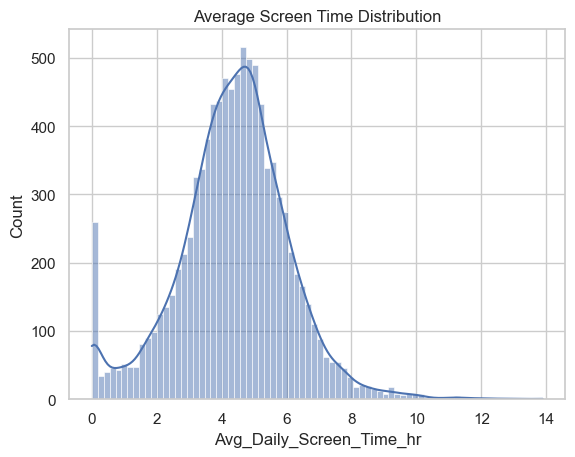

In [68]:
# Calculation of skewness in data distribution
skew_val = df_data['Avg_Daily_Screen_Time_hr'].skew()
print(f" Skewness Value: {skew_val}")

# Dstribution Visualization
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df_data['Avg_Daily_Screen_Time_hr'], kde=True) #KDE provides a smooth curved line to show the overall shape of the distribution.
plt.title("Average Screen Time Distribution")        #True : KDE is False so Seaborn only displays the histogram (bars) and needs to be set to True to instruct the program to calculate and display the estimated data density.
plt.show()

Based on the data, it shows that the duration of screen use is skewed to the right (Positively Skewed), where the average value is greater than the median due to the presence of a group of children with very high usage.

In [69]:
# View the division of screen time categories
bins = [0, 2, 4, 6, 10]
labels = ['Low', 'Medium', 'High', 'Very High']
print(pd.cut(df_data['Avg_Daily_Screen_Time_hr'], bins=bins, labels=labels).value_counts())

Avg_Daily_Screen_Time_hr
High         4596
Medium       2930
Very High    1326
Low           606
Name: count, dtype: int64


### - Data Type Division


**- Data Numeric**

Columns that contain numbers and can be used for mathematical calculations.


| **Column**                        | **Data Type Details**                                                                           |
|-----------------------------------|-------------------------------------------------------------------------------------------------|
| Age                               | Integer (int64). Represents the child's age in the range of 8–18 years.                         |
| Avg_Daily_Screen_Time_hr          | Float (float64). Represents time duration in hours range by decimal numbers.                    |
| Educational_to_Recreational_Ratio | Float (float64). Represents the ratio between educational and recreational content (0.0 to 1.0).|


**- Data Categoric**

Columns containing labels or groups of data.

| **Column**                        | **Data Type Details**                                                                        |
|-----------------------------------|----------------------------------------------------------------------------------------------|
| Gender                            | Object. Contains the category "Male" or "Female"                                             |
| Primary_Device                    | Object. Contains device categories such as "Smartphone", "Laptop", "TV", or "Tablet"         |
| Health_Impacts                    | Object. Contains health impact labels such as "Poor Sleep" or "Eye Strain"                   |
| Urban_or_Rural                    | Object. Contains the residential location category, namely "Urban" or "Rural"                |
| Exceeded_Recommended_Limit        | Boolean, namely True or False. Contains a Boolean truth value.                               |

### - Duplicate and Missing Value Indications

In [70]:
print("\n-----Missing Value Indication:-----")
print(df_data.isnull().any())

print("\n-----Total Missing Value:-----")
print(df_data.isnull().sum())

print(f"\n-----Duplicates Detected:----- {df_data.duplicated().sum()}")


-----Missing Value Indication:-----
Age                                  False
Gender                               False
Avg_Daily_Screen_Time_hr             False
Primary_Device                       False
Exceeded_Recommended_Limit           False
Educational_to_Recreational_Ratio    False
Health_Impacts                        True
Urban_or_Rural                       False
dtype: bool

-----Total Missing Value:-----
Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

-----Duplicates Detected:----- 44


In [71]:
missing_value_percentage = df_data.isnull().mean() * 100
print("Missing Value (%):")
print(missing_value_percentage.round(2))

Missing Value (%):
Age                                   0.00
Gender                                0.00
Avg_Daily_Screen_Time_hr              0.00
Primary_Device                        0.00
Exceeded_Recommended_Limit            0.00
Educational_to_Recreational_Ratio     0.00
Health_Impacts                       33.13
Urban_or_Rural                        0.00
dtype: float64


In [72]:
#Duplicate Percentages in Rows
total_duplicates = df_data.duplicated().sum()

duplicate_percentage = (total_duplicates / len(df_data)) * 100

print(f"Total Duplicate Rows: {total_duplicates}")
print(f"Duplicate Percentage Data: {duplicate_percentage:.2f}%")

Total Duplicate Rows: 44
Duplicate Percentage Data: 0.45%


Based on initial exploration, two findings emerged from the data:

1. This dataset has a total of 9,712 entries (rows). The Health_Impacts column only has 6,494 non-null entries (filled-in data). This indicates that there are 3,218 rows (approximately 33% of the total data) where information regarding health impacts is missing or empty.

2. Although the dataset appears complete, upon further inspection, 33% of the values in the "Health Impact" column are missing. This can lead to inaccurate statistical calculations because the number of valid values varies across columns.

3. The distribution table shows a long tail to the right: Most children spend 2–4 hours a day using screens, but there is a small group (outliers) who spend up to 7–9 hours a day using screens, which leads to a higher average value.

A duplicate data check revealed 44 rows, representing 0.45%.

Although no outliers were found in the age column, the data can be further classified into child and adolescent age groups based on the World Health Organization (WHO) psychological and physiological developmental stages of children and adolescents.

Lower Limit (min): 8 years

Upper Limit (max): 18 years

This age range (8–18 years) is very reasonable and consistent, but it requires categorization.

   

## b. Missing Values, Duplicates, Space Extras Handling

To improve the accuracy of future analysis, Data Cleaning needs to be performed to ensure that decisions made based on the *Indian Kids Screen Time* dataset are unbiased. The following are the steps taken : 

In [73]:
import numpy as np
import pandas as pd

# A. Normalize empty values to NaN
df_data = df_data.replace(['nan', 'None', '', ' '], np.nan)

# B. Identify category columns
kategori_cols = df_data.select_dtypes(include=['object']).columns

# C. Fill in missing values, tidy up spaces, and standardize capitalization within a block.
for col in kategori_cols:
    # Fill with Unknown, space deleting, and change it to Title Case
    df_data[col] = df_data[col].fillna("Unknown").astype(str).str.strip().str.title()

# D. Duplicates deleting
df_data = df_data.drop_duplicates()

print("\n-----Missing Value Indication:-----")
print(df_data.isnull().any())

# Display Missing Values
print("\n-----Total Missing Values:-----")
print(df_data.isnull().sum())

# Duplication Checking
print(f"\n-----Duplicate amount:----- {df_data.duplicated().sum()}")

print("Missing values pada kolom kategori:\n", df_data[kategori_cols].isnull().sum())
print(f"The amount of rows after cleaning process: {len(df_data)}")



-----Missing Value Indication:-----
Age                                  False
Gender                               False
Avg_Daily_Screen_Time_hr             False
Primary_Device                       False
Exceeded_Recommended_Limit           False
Educational_to_Recreational_Ratio    False
Health_Impacts                       False
Urban_or_Rural                       False
dtype: bool

-----Total Missing Values:-----
Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64

-----Duplicate amount:----- 0
Missing values pada kolom kategori:
 Gender            0
Primary_Device    0
Health_Impacts    0
Urban_or_Rural    0
dtype: int64
The amount of rows after cleaning process: 9668


In [93]:
df_ab=df_data   #Menyimpan variabel df_ab sebelum penambahan kolom dan encoding untuk tujuan visualisasi. 
df_ab[['Primary_Device', 'Exceeded_Recommended_Limit']]

,Primary_Device,Exceeded_Recommended_Limit
0,Smartphone,True
1,Laptop,True
2,TV,True
3,Laptop,False
4,Smartphone,True
...,...,...
9707,Smartphone,True
9708,Smartphone,True
9709,Smartphone,True
9710,TV,True


Notes on *Data Cleaning* in the first step: 

- Even though at the data exploration stage, no excessive spaces and non-uniform capital letters were found, thorough cleaning is still required to ensure the data is truly clean.
- Checking for empty values in columns is carried out as a 'before and after' comparison logic. Cleaning is done accurately. Using "Unknown" and continuing with drop_duplicates() is to avoid wrong assumptions (not guessing data with the mode) without having to delete rows or columns that have empty values.


In [9]:
df_clean = df_data

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9668 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9668 non-null   int64  
 1   Gender                             9668 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9668 non-null   float64
 3   Primary_Device                     9668 non-null   object 
 4   Exceeded_Recommended_Limit         9668 non-null   bool   
 5   Educational_to_Recreational_Ratio  9668 non-null   float64
 6   Health_Impacts                     9668 non-null   object 
 7   Urban_or_Rural                     9668 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 613.7+ KB


## c. Identify Outliers (By IQR Method)

In [11]:
# Selecting a numeric column (Avg_Daily_Screen_Time_hr)
target_col = 'Avg_Daily_Screen_Time_hr'

# Calculating Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_clean[target_col].quantile(0.25)
Q3 = df_clean[target_col].quantile(.75)
IQR = Q3 - Q1

# Determine the lower limit and upper limit
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_iqr = df_clean[(df_clean[target_col] < lower_bound) | (df_clean[target_col] > upper_bound)]

print(f"Upper Bound: {upper_bound}")
print(f"Outliers (IQR): {len(outliers_iqr)}")

Upper Bound: 8.30875
Outliers (IQR): 428


In [12]:
# Selecting a numeric column (Educational_to_Recreational_Ratio)
target_col = 'Educational_to_Recreational_Ratio'

# Calculating Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_clean[target_col].quantile(0.25)
Q3 = df_clean[target_col].quantile(0.75)
IQR = Q3 - Q1

# Determine the lower limit and upper limit
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_iqr = df_clean[(df_clean[target_col] < lower_bound) | (df_clean[target_col] > upper_bound)]

print(f"Upper Bound: {upper_bound}")
print(f"Outliers (IQR): {len(outliers_iqr)}")

Upper Bound: 0.645
Outliers (IQR): 0


In [13]:
# Selecting a numeric column (Age)
target_col = 'Age'

# Calculating Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_clean[target_col].quantile(0.25)
Q3 = df_clean[target_col].quantile(0.75)
IQR = Q3 - Q1

# Determine the lower limit and upper limit
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_iqr = df_clean[(df_clean[target_col] < lower_bound) | (df_clean[target_col] > upper_bound)]

print(f"Upper Bound: {upper_bound}")
print(f"Outliers (IQR): {len(outliers_iqr)}")

Upper Bound: 25.0
Outliers (IQR): 0


In [14]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9668 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9668 non-null   int64  
 1   Gender                             9668 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9668 non-null   float64
 3   Primary_Device                     9668 non-null   object 
 4   Exceeded_Recommended_Limit         9668 non-null   bool   
 5   Educational_to_Recreational_Ratio  9668 non-null   float64
 6   Health_Impacts                     9668 non-null   object 
 7   Urban_or_Rural                     9668 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 613.7+ KB


Reasons for choosing a numeric column to identify outliers:  
- Avg_Daily_Screen_Time_hr 

This is the most important column because it is the main variable in the analysis of this dataset.  


- Educational_to_Recreational_Ratio

Sometimes the total screen time looks normal (e.g. 5 hours), but in the details column a number is written that is beyond logic (e.g. recreation time 20 hours). 


- Age (Age)
  
Even though age has a certain range, it still needs to be checked. The reason is that this dataset is usually intended for the "Kids" category (Children/Teenagers). If there is data with an age of 0, 1, or over 20 years (for example 99 years), then the data is an outlier or input error that must be cleaned.


- Discovery during Data Exploration 

Using (df_data.describe() during data exploration shows that the "max" row in the (Age) column and (Avg_Daily_Screen_Time_hr) has a higher value than the (Educational_to_Recreational_Ratio) column, which indicates an upper outlier. In addition, if the value is 0 (in the age/hour column) in the "min" row, it is a lower outlier or an indication of incorrect data.

## d. Outliers Handling


To handle outliers, *Capping* as a method is used to maintain the sample size without having to discard rows of data. Before *Capping* is carried out, we need to display details of the outliers before and after the *capping* process.  *Capping* is a technique for handling outliers by replacing extreme values that are outside a certain limit with the threshold value. *Capping* still maintains the number of rows (observations) but changes the value so that it is not too far from the normal distribution.

A simpler picture can be obtained from one of the *Boxplot* features in the matplotlib library.

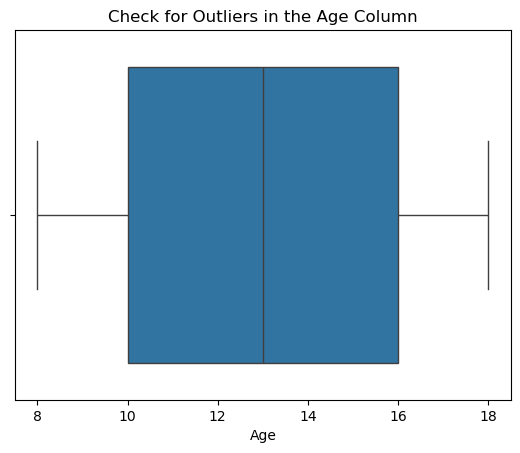

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot Visualization
sns.boxplot(x=df_clean['Age'])
plt.title('Check for Outliers in the Age Column')
plt.show()

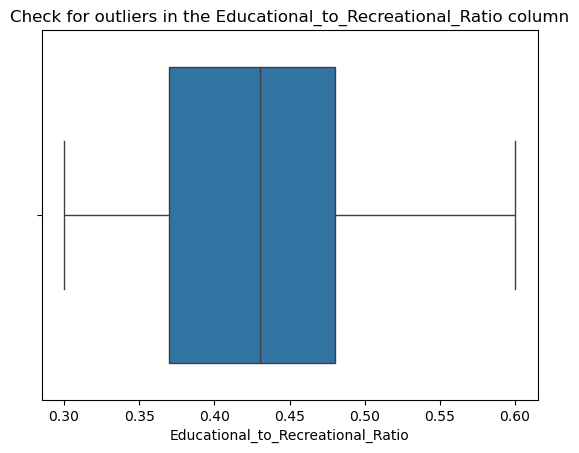

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot Visualization
sns.boxplot(x=df_clean['Educational_to_Recreational_Ratio'])
plt.title('Check for outliers in the Educational_to_Recreational_Ratio column')
plt.show()

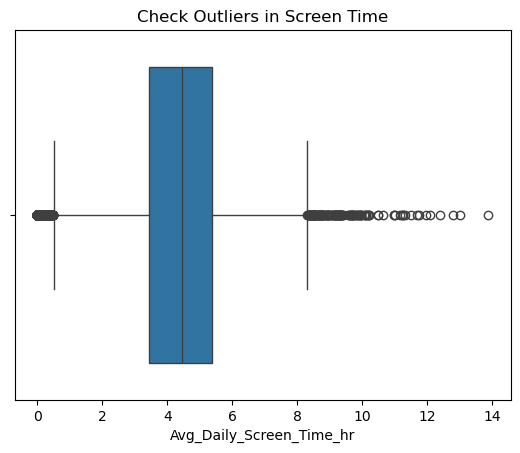

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot Visualization
sns.boxplot(x=df_clean['Avg_Daily_Screen_Time_hr'])
plt.title('Check Outliers in Screen Time')
plt.show()

After a simple visualization of the Boxplot appears, it can be seen that there are points in the 'Avg_Daily_Screen_Time_hr' column, but not in other columns. Points that are statistically referred to as *outliers* that appear outside the *Whisker* line (the line that extends up and down from the main box in a Box Plot) are statistically referred to as *outliers. This line is called the *Upper Bound* or upper limit which is the highest limit that is considered "reasonable" in a data set.


In [18]:
# Calculate Q1 (25th Percentile)
Q1 = df_clean['Avg_Daily_Screen_Time_hr'].quantile(0.25)

# Calculate Q3 (75th Percentile)
Q3 = df_clean['Avg_Daily_Screen_Time_hr'].quantile(0.75)

# Calculate the rela  IQR
IQR = Q3 - Q1

print(f"Value of Q1: {Q1}")
print(f"Value of Q3: {Q3}")
print(f"IQR amount: {IQR}")

Value of Q1: 3.4275
Value of Q3: 5.38
IQR amount: 1.9524999999999997


In [19]:
# statistic counting
Q1 = df_clean['Avg_Daily_Screen_Time_hr'].quantile(0.25)
Q3 = df_clean['Avg_Daily_Screen_Time_hr'].quantile(0.75)
IQR = Q3 - Q1

# To get the upper limit, multiply by 1.5
upper_bound = Q3 + 1.5 * IQR 

print(f"Upper Bound Based on Boxplot: {upper_bound}")

Upper Bound Based on Boxplot: 8.30875


In [20]:
# Capping execution starts
Q1 = df_clean['Avg_Daily_Screen_Time_hr'].quantile(0.25)
Q3 = df_clean['Avg_Daily_Screen_Time_hr'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


df_data['Avg_Daily_Screen_Time_hr'] = df_clean['Avg_Daily_Screen_Time_hr'].clip(lower=lower_limit, upper=upper_limit)

# Check results (Max value will not exceed upper_limit)
print("New Maximum Value:", df_clean['Avg_Daily_Screen_Time_hr'].max())

New Maximum Value: 8.30875


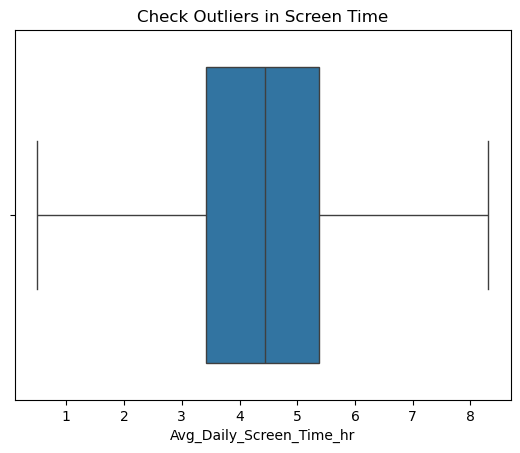

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot Visualization
sns.boxplot(x=df_clean['Avg_Daily_Screen_Time_hr'])
plt.title('Check Outliers in Screen Time')
plt.show()

By this method, *outliers* have been successfully resolved. So in the *Indian Kids Screen Time* data, high values may not be input errors, but real behavior. With *Capping*, we still respect the data that the child has "high" screen time, without letting the extreme numbers confuse the calculation of the average (mean).

Skewness Value: -0.19065378977664493


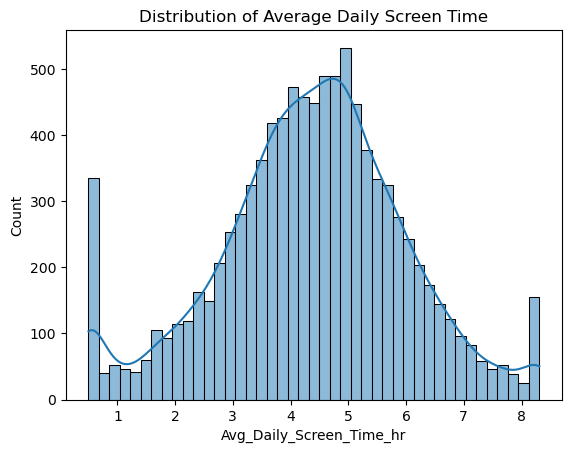

In [22]:
# Calculation of skewness in data distribution
skew_val = df_clean['Avg_Daily_Screen_Time_hr'].skew()
print(f"Skewness Value: {skew_val}")

# Distribution visualization
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df_clean['Avg_Daily_Screen_Time_hr'], kde=True) # KDE provides smooth curved lines to show the overall shape of the distribution
plt.title("Distribution of Average Daily Screen Time")         
plt.show()


After handling outliers, the majority of Data (Normal Distribution): Most respondents had an average daily screen time of between 3 to 7 hours, with the peak (highest frequency) being around 5 hours per day. The data distribution curve in this range resembles a symmetrical bell shape, characteristic of a normal distribution.

The reason for replacing the empty value with "Unknown" is because the empty value is the "Health_Impacts" column which is of categorical type or *string*. This is due to being able to maintain data integrity. 

The reason for not deleting rows that have blank values is because it can result in the loss of important data from other columns (such as screen time duration or age) that is needed for further analysis later. By labeling it "Unknown", data from other column rows can still be analyzed.

In [23]:
df_data

# Check again for missing values
print("--- Readiness Status and Data Cleanliness ---")
print(df_clean.isnull().sum())

--- Readiness Status and Data Cleanliness ---
Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64


Steps to ensure clean data have been carried out and for clean dataset variables, the df_data variable can be used for the next step.

## e. Data Type Conversion

After the data cleaning process is carried out, using the correct data type through data type conversion is very important to ensure calculation accuracy, save memory usage (RAM), and prevent errors during data processing. The first step is to ensure that each column has the appropriate data type so that mathematical and logical operations run accurately.

The following is the data type conversion process:

In [76]:
import pandas as pd

# Numerical Conversion with manual cleanup
num_cols = ['Avg_Daily_Screen_Time_hr', 'Age']
for col in num_cols:
    if col in df_data.columns:
        # Removes non-numeric characters so astype(float) doesn't error
        df_clean[col] = df_clean[col].astype(str).str.extract(r'(\d+\.?\d*)')[0]  #r'(\d+\.?\d*)' is a regex pattern (to search for numbers)
        df_clean[col] = df_clean[col].fillna(0).astype(float)                     #\d+ : Search for one or more numbers (0-9).
                                                                                #\.? : Looking for a period (decimal) if there is one. Question mark ? means the point is optional (may be there, may not be).
                                                                                # \d* : Looking for additional digits after the decimal point (if any).

# Category conversion
cat_cols = ['Gender', 'Primary_Device', 'Urban_or_Rural', 'Health_Impacts']
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

#  Boolean conversion
if 'Exceeded_Recommended_Limit' in df_clean.columns:
    df_clean['Exceeded_Recommended_Limit'] = df_clean['Exceeded_Recommended_Limit'].astype(bool)

print("\n--- Data Type After Conversion ---")
print(df_clean.dtypes)


--- Data Type After Conversion ---
Age                                   float64
Gender                               category
Avg_Daily_Screen_Time_hr              float64
Primary_Device                       category
Exceeded_Recommended_Limit               bool
Educational_to_Recreational_Ratio     float64
Health_Impacts                       category
Urban_or_Rural                       category
Age_Category                           object
Health_Impacts_Freq                   float64
dtype: object


The following is a summary of data type changes made to optimize memory usage (to make data lighter) and ensure consistency of analysis before and after conversion:

| **Column**                        | **Data Type Before Conversion**  |**Data Type After Conversion**       |
|-----------------------------------|----------------------------------|-------------------------------------|
| Age                               | int64                            | int64                               |
| Gender                            | object                           | category                            |
| Avg_Daily_Screen_Time_hr          | float64                          | float64                             |
| Primary_Device                    | object                           | category                            |
| Exceeded_Recommended_Limit        | bool                             | bool                                |
| Educational_to_Recreational_Ratio | float64                          | float64                             |
| Health_Impacts                    | object                           | category                            |
| Urban_or_Rural                    | object                           | category                            |



The following are the objectives of the data type conversion based on what has been done: 

-Numeric (int/float) for accurate statistical and mathematical calculations.

-Category to significantly save RAM and speed up code execution duration.

-Boolean (Bool) to simplify the filtering logic (Filter) "Yes" or "No".

## f. New Column Via Engineering Feature

To make it easier to carry out analysis later, the new column that needs to be created is a column grouping young children and teenagers for children's ages in order to see trends in digital behavior (Age_Category), for the reason that even though no outliers were found, age classification will be very important for categorizing the ages of children to teenagers.

In [83]:
# Toddler: < 5, Kids: 5-12, Teen: > 12
df_clean['Age_Category'] = df_clean['Age'].apply(
    lambda x: 'Toddler' if x < 5 else ('Kids' if x <= 12 else 'Teen')
)

print(df_clean.columns) # To check whether the new column name is in the list
print(df_clean.head(5))  
print(df_clean.info())

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural', 'Age_Category',
       'Health_Impacts_Freq'],
      dtype='object')
    Age Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0  14.0      1                      3.99              1   
1  11.0      0                      4.61              0   
2  18.0      0                      3.73              3   
3  15.0      0                      1.21              0   
4  12.0      0                      5.89              1   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                    

## g. Encoding Data

In addition to output, data encoding is included in Data Preparation to ensure information can be processed, sent or stored effectively by the computer system later. Based on the *Indian_Kids_Screen_Time_Standardized.csv* dataset, the categorical columns that require encoding are Gender, Primary_Device, Health_Impacts, and Urban_or_Rural.

In [84]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_kids = df_clean  #stores data for encoding with different variables.

# Gender Encoding (Converting to 0 and 1)
df_kids['Gender'] = le.fit_transform(df_kids['Gender'])

# Encoding Urban_or_Rural (Changes to 0 and 1)
df_kids['Urban_or_Rural'] = le.fit_transform(df_kids['Urban_or_Rural'])

# Encoding Exceeded_Recommended_Limit (Converts Boolean/Text to 0 and 1)
df_kids['Exceeded_Recommended_Limit'] = le.fit_transform(df_kids['Exceeded_Recommended_Limit'])

df_kids.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Category,Health_Impacts_Freq
0,14.0,1,3.99,1,1,0.42,"Poor Sleep, Eye Strain",1,Teen,0.101158
1,11.0,0,4.61,0,1,0.30,Poor Sleep,1,Kids,0.234175
2,18.0,0,3.73,3,1,0.32,Poor Sleep,1,Teen,0.234175
3,15.0,0,1.21,0,0,0.39,Unknown,1,Teen,0.328920
4,12.0,0,5.89,1,1,0.49,"Poor Sleep, Anxiety",1,Kids,0.062784


Based on the process carried out, all categorical columns 'Gender', 'Urban_or_Rural' 'Exceeded_Recommended_Limit' have been changed to numbers. The reason for using the Label Encoder is because the two columns have a single variable or there are no additional variables.

In [85]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#Converting the Primary_Device and Age_Category columns into numbers (example: 0, 1) so that the data can be processed by machine learning algorithms that only accept mathematical input.
df_kids['Primary_Device'] = le.fit_transform(df_kids['Primary_Device'])

# Encoding (Converts to 0 and 1)
df_kids['Age_Category'] = le.fit_transform(df_kids['Age_Category'])

df_kids.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Category,Health_Impacts_Freq
0,14.0,1,3.99,1,1,0.42,"Poor Sleep, Eye Strain",1,1,0.101158
1,11.0,0,4.61,0,1,0.30,Poor Sleep,1,0,0.234175
2,18.0,0,3.73,3,1,0.32,Poor Sleep,1,1,0.234175
3,15.0,0,1.21,0,0,0.39,Unknown,1,1,0.328920
4,12.0,0,5.89,1,1,0.49,"Poor Sleep, Anxiety",1,0,0.062784


The Primary_Device and Age_Category columns have more than one variable, so the encoding method chosen is Encoding One Hot Encoding.

In [28]:
# Calculate the frequency of each category in the Health_Impacts column
freq_map = df_kids['Health_Impacts'].value_counts(normalize=True)

print("Map Frequency:", freq_map) #Print a "dictionary" of frequencies onto the screen so that categories can be verified which are the most dominant (have values ​​close to 1.0) and which are rare.

df_kids['Health_Impacts_Freq'] = df_kids['Health_Impacts'].map(freq_map)

df_kids[['Health_Impacts', 'Health_Impacts_Freq']].head()

Map Frequency: Health_Impacts
Unknown                                          0.328920
Poor Sleep                                       0.234175
Poor Sleep, Eye Strain                           0.101158
Eye Strain                                       0.066612
Poor Sleep, Anxiety                              0.062784
Poor Sleep, Obesity Risk                         0.046752
Anxiety                                          0.039822
Poor Sleep, Eye Strain, Anxiety                  0.026686
Obesity Risk                                     0.026065
Poor Sleep, Eye Strain, Obesity Risk             0.019446
Eye Strain, Anxiety                              0.013964
Eye Strain, Obesity Risk                         0.010964
Poor Sleep, Anxiety, Obesity Risk                0.008068
Anxiety, Obesity Risk                            0.007137
Poor Sleep, Eye Strain, Anxiety, Obesity Risk    0.003827
Eye Strain, Anxiety, Obesity Risk                0.003620
Name: proportion, dtype: float64


,Health_Impacts,Health_Impacts_Freq
0,"Poor Sleep, Eye Strain",0.101158
1,Poor Sleep,0.234175
2,Poor Sleep,0.234175
3,Unknown,0.328920
4,"Poor Sleep, Anxiety",0.062784


For categorical columns, Frequency Encoding is carried out, because in one column there are more than two or 3 varying variables. So each category is converted into a number based on the frequency of its occurrence. How to check that all encodings are successful can be seen from:

In [29]:
df_kids.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Category,Health_Impacts_Freq
0,14.0,1,3.99,1,1,0.42,"Poor Sleep, Eye Strain",1,1,0.101158
1,11.0,0,4.61,0,1,0.30,Poor Sleep,1,0,0.234175
2,18.0,0,3.73,3,1,0.32,Poor Sleep,1,1,0.234175
3,15.0,0,1.21,0,0,0.39,Unknown,1,1,0.328920
4,12.0,0,5.89,1,1,0.49,"Poor Sleep, Anxiety",1,0,0.062784


After creating a new column with Health_Impact_Frec, the old 'Health Impact' column is taken out and saved to a new variable.

In [30]:
# Removed the 'health impact' column and kept it in df_kids_clean
df_add = df_kids

df_add = df_kids.drop(columns=['Health_Impacts'])

# using parameter axis=1
df_add = df_kids.drop('Health_Impacts', axis=1)

df_add.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Urban_or_Rural,Age_Category,Health_Impacts_Freq
0,14.0,1,3.99,1,1,0.42,1,1,0.101158
1,11.0,0,4.61,0,1,0.30,1,0,0.234175
2,18.0,0,3.73,3,1,0.32,1,1,0.234175
3,15.0,0,1.21,0,0,0.39,1,1,0.328920
4,12.0,0,5.89,1,1,0.49,1,0,0.062784


By changing the column in the df_add variable, the "Health_Impact" column is calculated with the frequency of its occurrence.

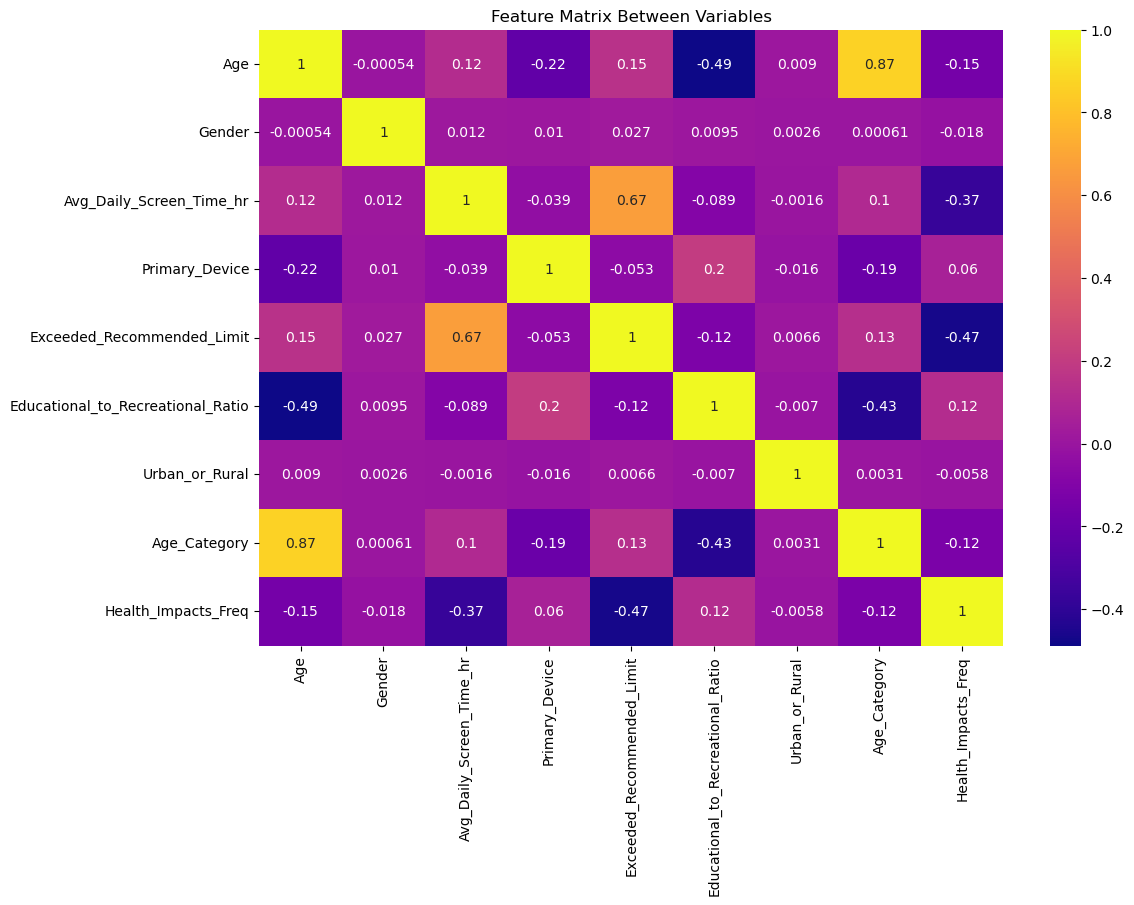

In [31]:
# It represents data with variables that are already in numerical form through Encoding.
df_kids['Health_Impacts_Freq'] = df_kids['Health_Impacts'].map(freq_map).astype(float)
plt.figure(figsize=(12, 8))
co_mtx = df_kids.corr(numeric_only=True) 

sns.heatmap(co_mtx, cmap="plasma", annot=True)
plt.title("Feature Matrix Between Variables")
plt.show()

In the Heatmap Graph, there is a conclusion that: 

- Strong positive correlation:

  There is a very strong positive correlation between Age (Age) and Age Category (Age_Category) (value 0.87), which is natural because the two variables represent similar information.
  
  There is a strong positive correlation between Average Daily Screen Time (Avg_Daily_Screen_Time_hr) and the Exceeded_Recommended_Limit variable (value 0.67). This suggests the higher the daily screen time, the more likely a person is to exceed the recommended limits.
  
- Strong negative correlation:

  The variable Education to Recreation Ratio (Educational_to_Recreational_Ratio) shows a strong negative correlation with Age (value -0.49) and Age Category (value -0.43). This indicates that the older a person is, the lower the ratio of screen time for educational purposes compared to recreation.

  There is a slight negative correlation between Avg_Daily_Screen_Time_hr and Educational_to_Recreational_Ratio (value -0.089), indicating a trend that increasing total daily screen time tends to slightly reduce the educational portion.

  Correlation indicates a statistical relationship or trend between variables, but does not prove a cause-and-effect relationship.

# 2. Exploratory Data Analysis

## a. Univariate Type

### - Percentage of Child Demographics and Child Age Category (Separate Variable)

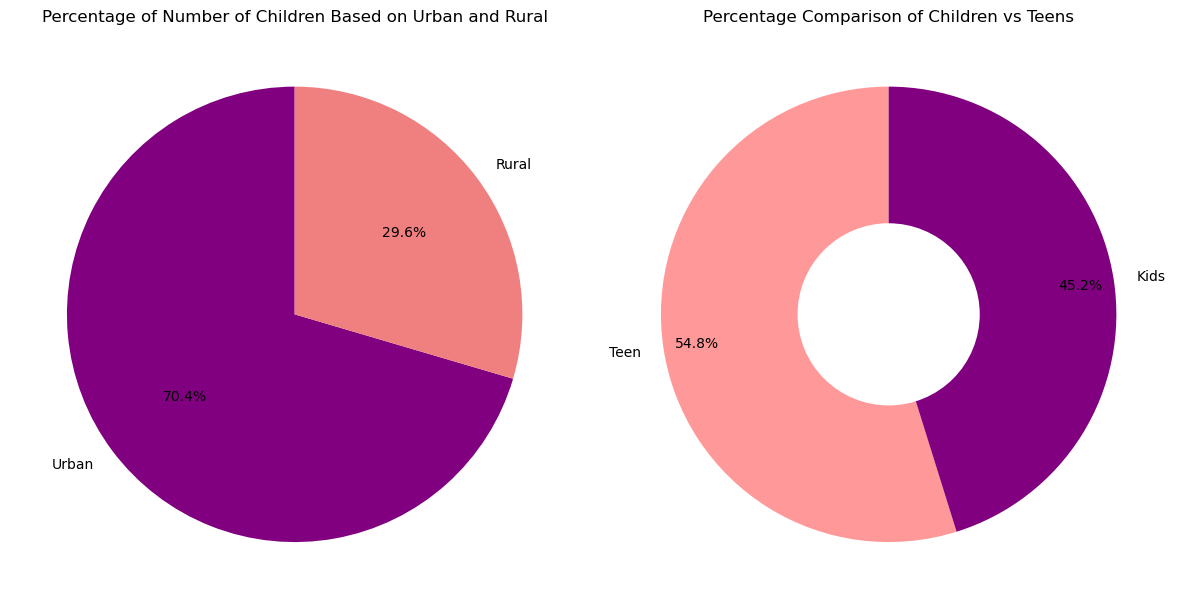

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Steps for Plot 1: Urban vs Rural (Pie Chart)
urban_rural_counts = df_clean['Urban_or_Rural'].value_counts()
label_mapping_1 = {0: 'Rural', 1: 'Urban'}
labeled_counts_1 = urban_rural_counts.rename(index=label_mapping_1)

ax[0].pie(
    labeled_counts_1.values, 
    labels=labeled_counts_1.index, 
    colors=['purple', 'lightcoral'],
    autopct='%1.1f%%',
    startangle=90
)
ax[0].set_title('Percentage of Number of Children Based on Urban and Rural')

# Steps for Plot 2: Kids vs Teen (Donut Chart)
data_counts_2 = df_kids['Age_Category'].value_counts()
label_mapping_2 = {0: 'Kids', 1: 'Teen'}
data_counts_2 = data_counts_2.rename(index=label_mapping_2)

ax[1].pie(
    data_counts_2, 
    labels=data_counts_2.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ff9999','#800080'], 
    pctdistance=0.85
)

# Make a hole in the middle for a donut effect
centre_circle = plt.Circle((0,0), 0.40, fc='white')
ax[1].add_artist(centre_circle)
ax[1].set_title('Percentage Comparison of Children vs Teens')

plt.tight_layout()
plt.show()

- Conclusion from the first chart: 

  Urban: Covers 70.4% of the total number of children.

  Rural: Covers 29.6% of the total number of children.

  More than double the number of children live in urban areas compared to those living in rural areas, based on data visualized by the rapid digital development in urban areas. 


- Conclusion from the second chart:

  The Teen category has a larger percentage than the Kids category. This is possible due to high needs with increasingly high levels of social activity in the teenage age range.

### - Distribution of Children's Daily Screen Time Density

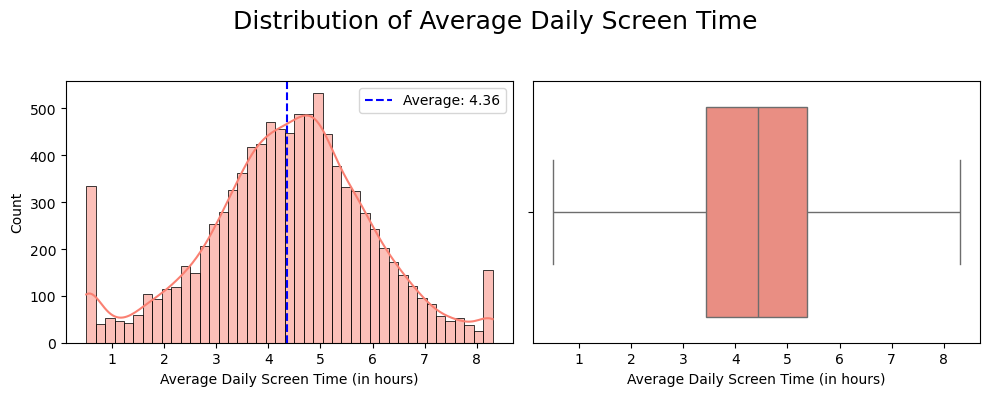

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize subplots
fig, axe = plt.subplots(1, 2, figsize=(10, 4))

# Histogram (First Axis / ax[0])
sns.histplot(data=df_clean, x='Avg_Daily_Screen_Time_hr', kde=True, ax=axe[0], color='salmon')
axe[0].set_xlabel('Average Daily Screen Time (in hours)')

# This is to add an average line to the histogram
mean_val = df_clean['Avg_Daily_Screen_Time_hr'].mean()
axe[0].axvline(mean_val, color='blue', linestyle='--', label=f'Average: {mean_val:.2f}')
axe[0].legend() # Showing 'Average' label in legend ax[0]

# Boxplot (Second Axis / ax[1])
sns.boxplot(data=df_clean, x='Avg_Daily_Screen_Time_hr', ax=axe[1], color='salmon')
axe[1].set_xlabel('Average Daily Screen Time (in hours)')

fig.suptitle('Distribution of Average Daily Screen Time', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.8)

plt.show()

Based on the combined histogram (left) and box plot (right), the following are the conclusions regarding the distribution of average daily screen time:

- Average Screen Time: The average daily screen time of this data sample was 4.36 hours.

    Data Centering: Most of the sample data is centered around the mean value. The distribution tends to be symmetrical or slightly skewed to the right, meaning there are slightly more people with very high screen time than with very low screen time.

- Data Distribution (Box Plot):

    Boxes represent the middle 50% of data (interquartile range). The line in the box shows the median (middle value), which looks very close to the mean value of 4.36 hours, confirming that the data is relatively centered. The horizontal line outside the box (whiskers) shows the overall distribution of the data, from minimum to maximum values, which range from about 0.5 hours to more than 8 hours. The length of the box and whiskers indicates the level of spread or diversity of the data.

Frequency: The highest frequency from respondents was in the range of 4 to 5 hours of screen time per day.

### - Distribution of Education to Entertainment Ratio

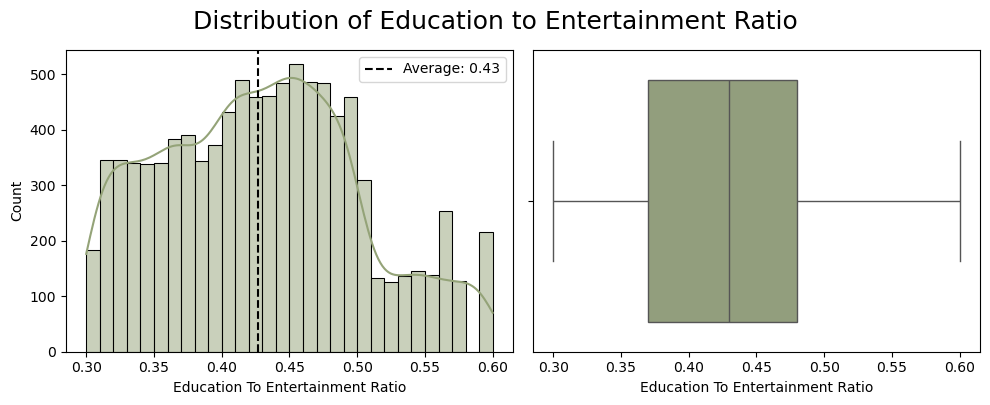

In [35]:
fig, axe = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(data=df_clean, x='Educational_to_Recreational_Ratio', kde=True, ax=axe[0], color='#94A378')
axe[0].set_xlabel('Education To Entertainment Ratio')

# This is to add an average line to the histogram
mean_val = df_clean['Educational_to_Recreational_Ratio'].mean()
axe[0].axvline(mean_val, color='Black', linestyle='--', label=f'Average: {mean_val:.2f}')
axe[0].legend() # Showing 'Average' label in legend ax[0]

sns.boxplot(data=df_clean, x='Educational_to_Recreational_Ratio',  ax=axe[1], color='#94A378')
axe[1].set_xlabel('Education To Entertainment Ratio')
fig.suptitle('Distribution of Education to Entertainment Ratio', fontsize=18, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

- Conclusion from the Histogram (left):

    Average Ratio: The average value of the ratio is 0.43, shown by the vertical dotted line in the histogram. Centered Data Distribution: The majority of data (peak distribution) is around the 0.40 to 0.50 range. This suggests that most observations have an education to entertainment ratio in that range.
  
    Skewed Right Distribution: Although the peak is around 0.45, the tail of the data appears longer towards the right (higher ratio value, closer to 0.60) than towards the left (ratio value 0.30), indicating the presence of some cases with higher ratios.
  
- Conclusion from the Box Plot (right):

    The median (center line of the box) appears slightly below 0.45. As much as 50% of the main data is in the box range, which is approximately between 0.38 to 0.48. The total spread of the data is in a wide range from 0.30 to 0.60.

 In general, it can be concluded that the most commonly observed ratio is slightly below 0.45, with a fairly even distribution of data in the middle range.

### - Data Distribution and Age Range of Children

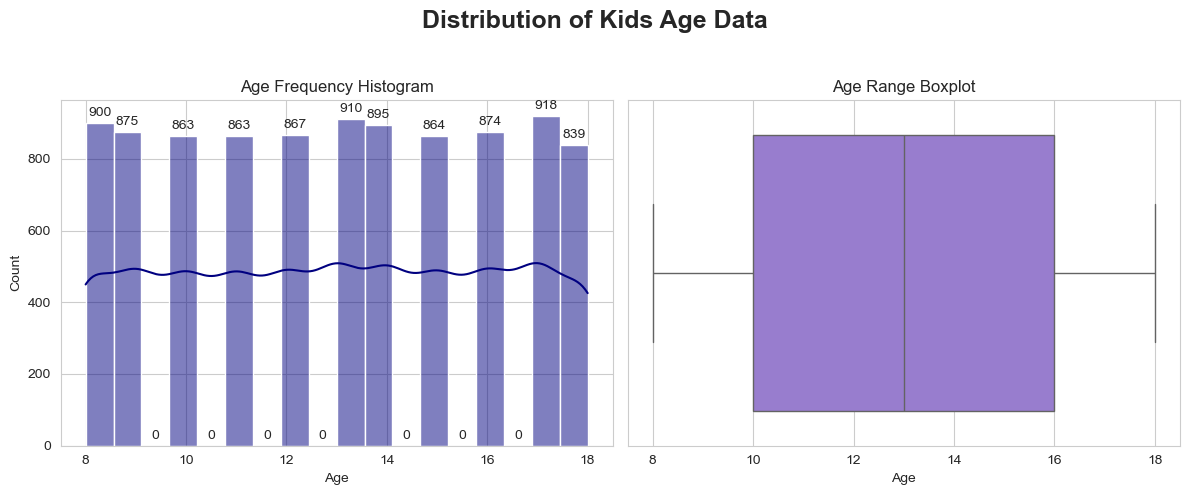

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# For visualization
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Histplot with Label Count
# Use dark blue (#000080)
plot1 = sns.histplot(data=df_clean, x='Age', kde=True, ax=axes[0], color='#000080')

# Added number labels above each bar
axes[0].bar_label(axes[0].containers[0], fmt='%d', padding=3)

axes[0].set_title('Age Frequency Histogram')

# 2. Boxplot
sns.boxplot(data=df_clean, x='Age', ax=axes[1], color='#9370DB')
axes[1].set_title('Age Range Boxplot')

# Main Title
fig.suptitle('Distribution of Kids Age Data', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.80)
plt.show()

Conclusion from the graph: 

- Age Frequency Histogram (Left): 
  Even Distribution: The bar graph shows that the number of users for each individual age (8, 9, 10, etc., up to 18) is almost the same, ranging from 839 to 918 users per age. The wavy dark blue line in the middle of the bar confirms the shape of the distribution which tends to be flat or uniform, indicating that no one age group dominates drastically.

- Age Range Boxplot (Right): 
Centered Data: The large, dense boxplot shows that most of the data (the middle 50%, in the dark blue box) is concentrated within a wide age range, perhaps between 10-16 years, reinforcing the impression of an even distribution.

## b. Bivariate Type

### -Number of Children Exceeding Recommended Screen Usage Limits

In [78]:
df_ab = pd.crosstab(columns=df_ab['Exceeded_Recommended_Limit'], index=df_ab['Primary_Device'])
df_ab

Exceeded_Recommended_Limit,False,True
Primary_Device,,
Laptop,158,1273
Smartphone,596,3944
Tablet,227,992
Tv,395,2083


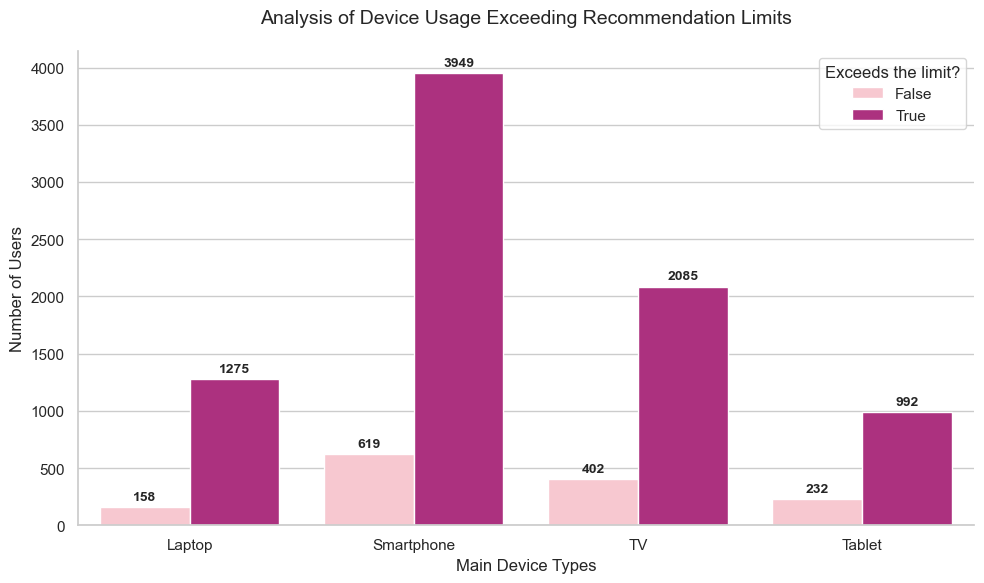

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_ab.reset_index().melt(id_vars='Primary_Device', value_name='Counts')

# Initialize visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Creating a Barplot (Grouped Bar Chart)
ax = sns.barplot(
    data=df_plot, 
    x='Primary_Device', 
    y='Counts', 
    hue='Exceeded_Recommended_Limit', 
    palette=['#FFC0CB', '#C11C84']
)

# Add a number label above each bar
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

# Customize Titles and Labels
plt.title('Analysis of Device Usage Exceeding Recommendation Limits', pad=20, fontsize=14)
plt.xlabel('Main Device Types', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.legend(title='Exceeds the limit?', loc='upper right')

# Tidy up the appearance
sns.despine() # Remove the top and right frame lines
plt.tight_layout()
plt.show()

Here are the main takeaways from the graph:

- Majority Overuse: Overall, orange bars (True / Exceeded) were significantly higher than purple bars (False / Not Exceeded) for each device category. This suggests that excessive device usage behavior is common among this data audience.

- Most Dominant Smartphone: Smartphone is the device with the highest number of users in absolute terms, both over the limit (3944) and not over the limit (596).

- Other Devices Are Also Significant: Tv, Laptop, and Tablet usage also shows the same pattern, where the number of users who exceed the limit is much greater than those who don't.

  
In short, the conclusion is that digital device use tends to exceed recommended time limits consistently across all device types.

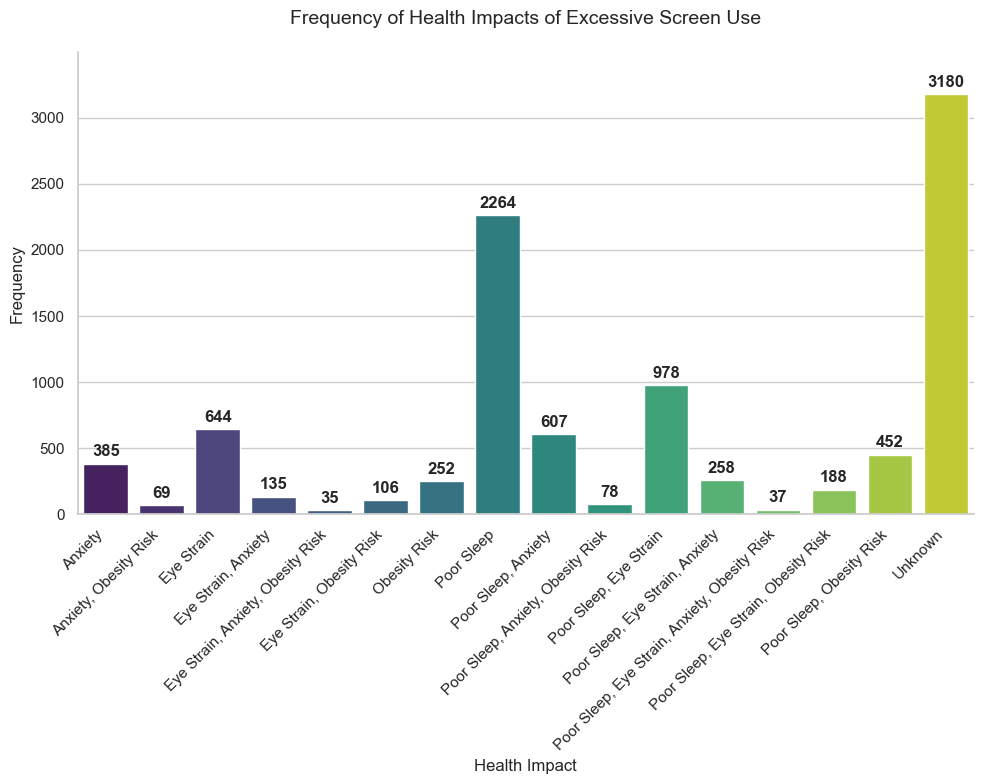

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter and calculate frequencies
filtered_df = df_clean[df_clean['Health_Impacts'] !='Missing']
counts = filtered_df['Health_Impacts'].value_counts()

plt.figure(figsize=(10, 8))

#Create a bar graph with category names on the X axis, numbers on the Y axis
#For different colors for each bar, use the Viridis color theme, and save the results in the variable ax so you can edit them further.
ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='viridis')

# For number labels
for i in ax.containers:
    ax.bar_label(i, padding=3, fontweight='bold')

plt.title("Frequency of Health Impacts of Excessive Screen Use", fontsize=14, pad=20)
plt.xlabel("Health Impact", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# The upper limit of the Y axis so that number labels are not truncated
plt.ylim(0, counts.max() * 1.1)

# Label slope
plt.xticks(rotation=45, ha='right')
sns.despine()

plt.tight_layout()
plt.show()

The following are the analysis points and conclusions from the data:

- Majority of Data is Unidentified: The “Unknown” category had the significantly highest frequency, namely 3,180, indicating that the majority of respondents or data entries did not provide specific health impacts or could not be classified into other available categories.
  
- "Poor Sleep" and "Eye Strain" Most Predominant Among Identified: Among the specific and identified health impacts, 'Poor Sleep' (Sleep Disorder) was the single most frequently reported condition (frequency 2,264), followed by 'Eye Strain' with a frequency of 644.

- In general, the graph shows that sleep disturbance is the most common specific impact, but there is a big challenge in classifying all impacts due to the very large portion of “Unknown”.

### - The Relationship Between Children's Age and Their Average Time in Front of the Screen Per Day

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample 100 rows (adjust n as needed)
df_sample = df_clean.sample(n=100, random_state=42)
df_sample

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Category,Health_Impacts_Freq
5204,12.0,1,4.53000,1,1,0.41,"Poor Sleep, Eye Strain",1,0,0.101158
2391,13.0,0,3.79000,0,1,0.31,Poor Sleep,0,1,0.234175
7705,13.0,0,4.22000,1,1,0.43,"Poor Sleep, Eye Strain",1,1,0.101158
2278,10.0,0,0.49875,1,0,0.48,Unknown,1,0,0.328920
4279,17.0,0,4.53000,0,1,0.44,Poor Sleep,0,1,0.234175
...,...,...,...,...,...,...,...,...,...,...
2651,11.0,0,3.25000,1,1,0.43,Eye Strain,0,0,0.066612
3034,13.0,1,5.65000,3,1,0.35,Poor Sleep,1,1,0.234175
321,8.0,1,3.93000,1,1,0.43,Unknown,1,0,0.328920
9364,12.0,1,4.70000,1,1,0.30,"Poor Sleep, Anxiety",1,0,0.062784


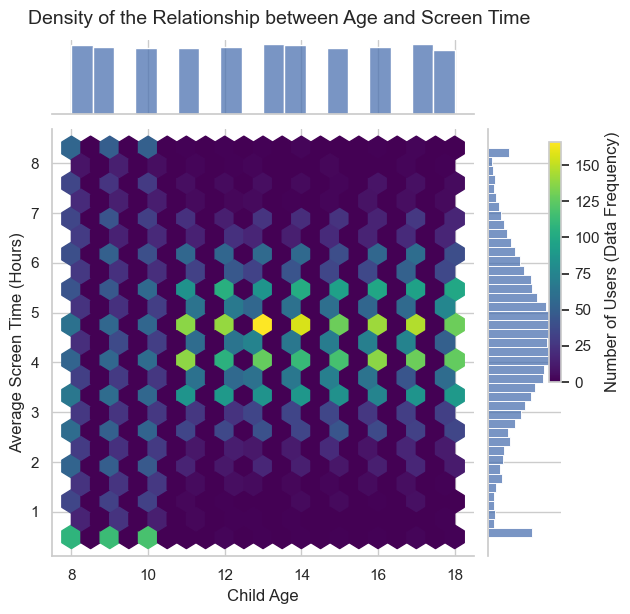

In [87]:
g = sns.jointplot(
    data=df_clean, 
    x='Age', 
    y='Avg_Daily_Screen_Time_hr', 
    kind='hex', # Using hexagons for data density
    cmap='viridis',
    gridsize=20
)

# Add a label to the colorbar
cbar_ax = g.fig.add_axes([.95, .4, .02, .4]) # Posisi manual [left, bottom, width, height]
plt.colorbar(cax=cbar_ax, label='Number of Users (Data Frequency)')

g.fig.suptitle("Density of the Relationship between Age and Screen Time", y=1.02, fontsize=14)
g.set_axis_labels("Child Age", "Average Screen Time (Hours)")
plt.show()

Conclusion from visualization: 

- Even Data Spread: The data points (represented by yellow/solid hexagons) are spread fairly evenly across the 8 to 18 age range, especially in the 4 to 6 hours of screen time per day.

- Most Common Screen Time: The highest density (bright yellow color) is concentrated in children who spend approximately 4 to 6 hours of screen time per day, regardless of their age.

- Age and Duration: There does not appear to be a clear pattern that older children (e.g. 16-18 years) consistently have significantly higher or lower screen time compared to younger children (e.g. 8-10 years).

- Upper Histogram (Age Distribution): Shows data frequency for "Child Age" (X-axis). It can be seen that the age distribution tends to be even or slightly increases at older ages.

- Right Histogram (Screen Time Distribution): Shows "Number of Users (Data Frequency)" (Y-axis). This shows that the majority of users have daily screen time in the range of 4-6 hours, with a sharp decline at higher levels of screen time (above 8 hours).

In general, the graph shows that the older a child gets in this range (8-18 years), the more likely they are to have an average daily screen time of around 4-6 hours, with the greatest concentration seen in the teenage age group.



## c.Multivariate Type

### - Correlation Matrix and Distribution of Numerical Variables

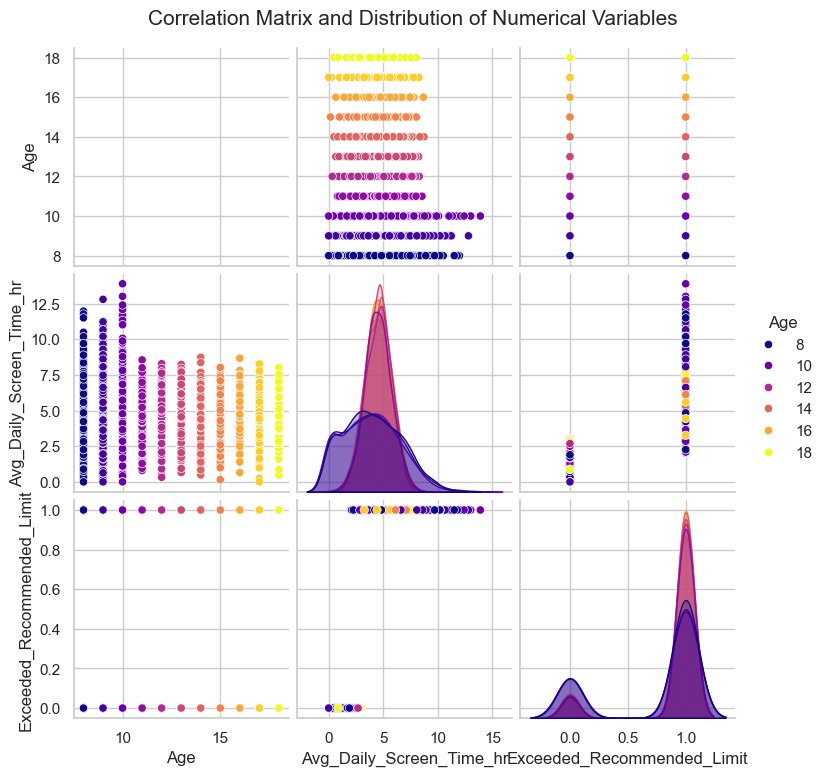

In [90]:
g = sns.pairplot(
    df_ab,
    vars=["Age", "Avg_Daily_Screen_Time_hr", "Exceeded_Recommended_Limit"],
    hue="Age",
    palette="plasma",
    diag_kind="kde"
)
g.fig.suptitle("Correlation Matrix and Distribution of Numerical Variables", y=1.03, fontsize=15)

plt.show()

This graph effectively shows:
There is a positive correlation between Age and Average Screen Time.
The "Exceeded_Recommended_Limit" variable is highly dependent on the other two variables, with children who are older and have more screen time tending to consistently exceed the recommended limits.


Overall, the data shows a general trend that screen time increases with age, and many exceed health recommended limits.

### - Correlation Matrix of Screen Time Against Primary Device

In [100]:
avg_screen_time_device = df_clean.groupby(['Primary_Device','Gender'])[['Avg_Daily_Screen_Time_hr']].agg({'Avg_Daily_Screen_Time_hr':['min','max','mean','median']})
avg_screen_time_device.columns = ['_'.join(col) for col in avg_screen_time_device.columns]
avg_screen_time_device.reset_index()

,Primary_Device,Gender,Avg_Daily_Screen_Time_hr_min,Avg_Daily_Screen_Time_hr_max,Avg_Daily_Screen_Time_hr_mean,Avg_Daily_Screen_Time_hr_median
0,0,0,0.49875,8.27000,4.480783,4.540
1,0,1,0.94000,7.81000,4.435549,4.435
2,1,0,0.49875,8.30875,4.360859,4.420
3,1,1,0.49875,8.30875,4.447582,4.520
4,2,0,0.49875,8.30875,4.215775,4.300
5,2,1,0.49875,8.30875,4.262073,4.410
6,3,0,0.49875,8.30875,4.290974,4.420
7,3,1,0.49875,8.30875,4.297684,4.380


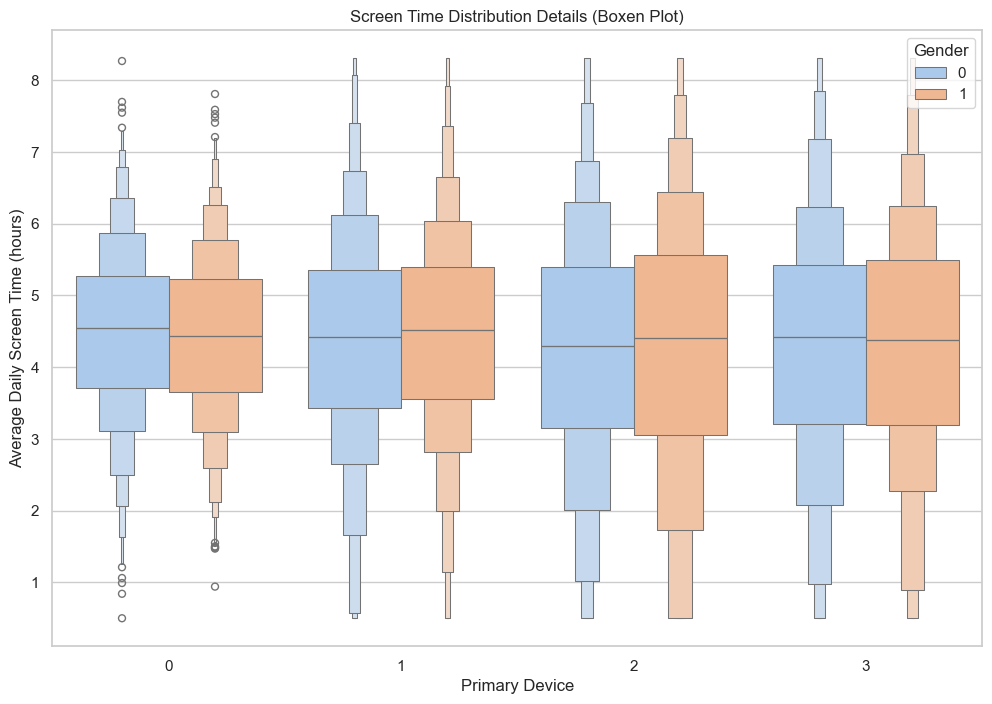

In [101]:
plt.figure(figsize=(12, 8))
sns.boxenplot(data=df_clean, x='Primary_Device', y='Avg_Daily_Screen_Time_hr', 
              hue='Gender', palette="pastel")

plt.xlabel('Primary Device')
plt.ylabel('Average Daily Screen Time (hours)')
plt.title('Screen Time Distribution Details (Boxen Plot)')
plt.show()

Conclusion from the graph: 

- Average Consistent Screen Time : The average (median, center line on the box) daily screen time tends to be consistent at 4.5 to 5 hours for almost all device and gender combinations.

- Majority of Users Are in the 3 to 6 Hour Range : Most of the data (interquartile range, i.e. the denser boxed area) shows that the majority of respondents spend between 3 to 6 hours of screen time per day across devices.

- Tablet Devices Show Higher Usage : Tablet users (both men and women) show a slightly higher distribution of screen time overall than users of other devices, with a median closer to 5.5 hours.

-Very Wide Distribution of Screen Time on Laptops : Laptop devices have the most extreme usage range. Although the average is the same as for other devices, the spread is very wide (from about 1 hour to more than 8 hours), and also shows many outliers (points outside the sharp edge) which means there is a small percentage of people who use the laptop much longer or much shorter than the average.

- Visually, there is no striking difference in screen time usage patterns between Male (light blue) and Female (light orange) across the four main device types. Both genders show almost identical distribution patterns and medians.

# 3. Insights and Conclusions


The following are brief conclusions and insights that summarize all points of analysis regarding the behavior of using digital devices in children (8-18 years):

- Main Conclusion: 

    In general, there is a high level of normalization of digital device use among children and teenagers. The majority of children live in urban areas (70.4%) with an average daily screen time of 4.36 hours, where the majority of respondents (especially teenagers) consistently exceed the recommended usage time limit (more than 4-6 hours per day). Smartphones remain the main device, but tablets show more intense usage duration.
  
- Strategic Insight:

  a. Urban & Digital Dominance: The high percentage of children in urban areas (70.4%) is directly proportional to massive digital access. This shows that the urban environment is the main driver of a sedentary lifestyle (lack of movement) in children.

  b. Education vs Entertainment Gap: The ratio of educational content to entertainment which is only 0.43 shows that device use is still dominated by entertainment. There is a huge opportunity to shift digital consumption towards educational content for more quality screen time.

  c. Neglected Health: Real impacts such as poor sleep and eye strain have emerged as major complaints. The high number in the "Unknown" category for health impacts provides a warning that there are many long-term health risks that users may not yet detect or be aware of.

- Device Characteristics:

  a. Smartphone: Is the daily tool that is most difficult to give up (largest number of users).

  b. Laptops: Have the most extreme variety of uses, possibly depending on schoolwork loads or heavy hobbies (such as gaming or editing).

  c. Tablet: Being the device with the highest usage duration, it needs to be watched out for as the main trigger for excessive screen time.

- Age Trends: There is no drastic difference in the number of users between ages (8-18 years), but as people get older into the teenage stage, the intensity and risk of exceeding recommended limits increases due to the need for digital social activities.